In [18]:
import os
from google.colab import drive
drive.mount('/content/drive')

#Define the folder where the data is stored
output_path = '/content/drive/MyDrive/thesis_data/output'
filepath = os.path.join(output_path, 'panel_all_years_sampled.csv')


Mounted at /content/drive


Loading data...
  Shape: (3792126, 15) — RAM: 595.6 MB

  NaN per colonna:
loan_age                     0
loan_term                    0
current_upb              34464
current_interest_rate    34187
estimated_ltv            34187
loan_amount                  0
original_ltv                 0
original_dti                 0
credit_score                 0
interest_rate                0
num_borrowers                0

Building PERSON-PERIOD dataset...
  Righe: 3,443,703 | Default: 9991 (0.29%)

Building STATIC dataset (t=0)...
  Righe: 99,970 | Default: 4296 (4.30%)

Building DYNAMIC dataset (landmarks + TVC)...
  Righe: 1,135,986 | Default: 32025 (2.82%)

Training STATIC model...
  Fold 1 — AUC: 0.6588
  Fold 2 — AUC: 0.6572
  Fold 3 — AUC: 0.6557
  Fold 4 — AUC: 0.6660
  Fold 5 — AUC: 0.6619

Training DYNAMIC model...
  Fold 1 — AUC: 0.7393
  Fold 2 — AUC: 0.7292
  Fold 3 — AUC: 0.7414
  Fold 4 — AUC: 0.7325
  Fold 5 — AUC: 0.7395

Training PERSON-PERIOD model...
  Fold 1 — AUC: 0.7277
  

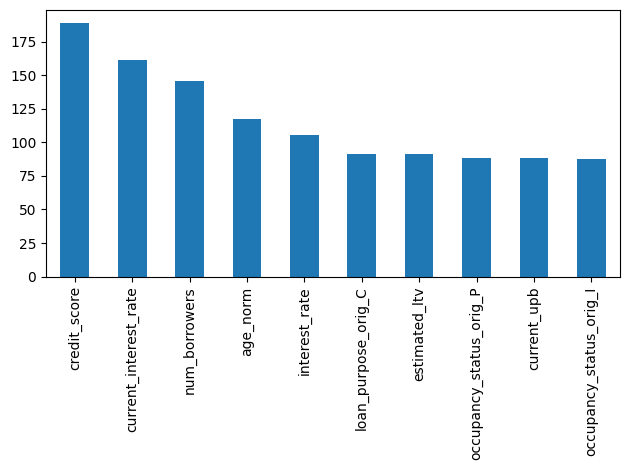

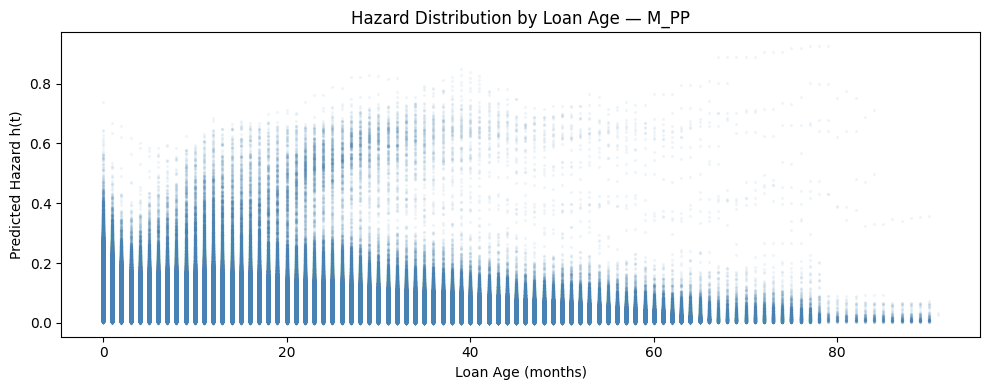


=== RISULTATI FINALI ===
    Model  AUC_Mean   AUC_SD  Brier_Mean  Brier_SD  F1_Mean    F1_SD  Time_Mean_sec  Time_SD_sec
 M_STATIC  0.659897 0.003681    0.056370  0.000691 0.036576 0.003903      10.098831     1.598135
M_DYNAMIC  0.736380 0.004693    0.040603  0.000344 0.131252 0.007399     111.380405     6.322607
     M_PP  0.732592 0.002571    0.006735  0.000044 0.041839 0.004092     206.805804    46.399880

=== DINAMICO — AUC PER LANDMARK ===
 Landmark  AUC_Mean  Brier_Mean  F1_Mean
        0  0.698218    0.069706 0.084531
        3  0.722804    0.057415 0.079051
        6  0.731436    0.053490 0.090517
        9  0.726967    0.050646 0.110444
       12  0.730614    0.048299 0.136490
       15  0.744311    0.043145 0.173333
       18  0.741081    0.039122 0.220077
       21  0.751310    0.036938 0.216667
       24  0.747766    0.034011 0.202899
       27  0.742557    0.031609 0.183333
       30  0.727930    0.029565 0.129252
       33  0.713886    0.026670 0.134921
       36  0.679

In [78]:
"""
FULL CREDIT RISK PIPELINE (ENGLISH COMMENTED VERSION)

Models evaluated:
    M_STATIC   : Static XGBoost (t=0 features, 12-month default target)
    M_DYNAMIC  : Dynamic XGBoost (landmark + TVC + hazard framing)
    M_PP       : Person-period XGBoost (next-step default prediction)
"""


# DA https://github.com/Samsara1247/Incorporating-data-drift-to-perform-survival-analysis-on-credit-risk/blob/main/Model%20prediction.py

import pandas as pd
import numpy as np
from pathlib import Path
import warnings, time, gc
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, brier_score_loss, f1_score
from sklearn.model_selection import GroupKFold
import xgboost as xgb

np.random.seed(42)

# Ignore future warnings from pandas
warnings.filterwarnings("ignore", category=FutureWarning)

# Input/output paths
DATA_PATH  = filepath
OUT_DIR   = Path("/content/out")
# create folder if not exists
OUT_DIR.mkdir(parents=True, exist_ok=True)

# prediction horizon and time checkpoints
HORIZON_MONTHS = 12
# Y(L,H)i = 1, if default happens in (L,L + H]
LANDMARKS = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48]



# Default if !=0
#CONVERTE I NaN IN 1 E' UNA ASSUNZIONE TROPPO FORTE MEGLIO DROP
'''
def is_default_vec(s):
    num = pd.to_numeric(s, errors="coerce").fillna(1)
    return (num != 0).astype(np.int8)
'''
def is_default_vec(s):
    num = pd.to_numeric(s, errors="coerce")
    return (num.notna() & (num != 0)).astype(np.int8)


# Comput evaluation metrics
def metrics_all(y_true, p, th=0.5):  #clip probabilities
    p   = np.clip(p, 0, 1)
    auc = roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    return dict(
        AUC   = auc,
        Brier = brier_score_loss(y_true, p),    #calibration error
        F1    = f1_score(y_true, (p >= th), zero_division=0) #classification error
    )

# Aggregate mean and standard deviation of metrics
def agg_mean_sd(list_of_dicts):
    out = {}
    for k in list_of_dicts[0].keys():
        vals = [d[k] for d in list_of_dicts]
        out[f"{k}_Mean"] = float(np.nanmean(vals))
        out[f"{k}_SD"]   = float(np.nanstd(vals))
    return out


# Train XGBoost model
def train_xgb(Xtr, ytr, Xte, yte):

    # --- class imbalance ---
    pos = (ytr == 1).sum()
    neg = (ytr == 0).sum()

    # --- DMatrix ---
    dtr = xgb.DMatrix(Xtr, label=ytr)
    dte = xgb.DMatrix(Xte, label=yte)


    bst = xgb.train(
    {   "objective": "binary:logistic",
        "eval_metric":      ["auc", "logloss"],
        "max_depth":        6,                     # tree depth
        "eta":              0.05,                  # learning rate
        "subsample":        0.8,                   # row sampling
        "colsample_bytree": 0.8,                   # feature sampling
        "scale_pos_weight": np.sqrt(neg / max(pos, 1)),    # imbalance handling      INVECE DI # invece di neg/pos PER AMMORBIDIRE SBILANCIAMNETO 0/1
        "seed":             42,                   # reproducibility
        "verbosity":        0,
        "nthread":          4,
        "tree_method":      "hist",              # faster histogram method
    },
    dtr, num_boost_round=500,        # max boosting rounds
    evals=[(dte, "test")],            # #validation set
    early_stopping_rounds=25,        #stop if no improvemnts
    #DATA LEAKAGE INTRODUCE CONOSCENZA DEL MODELLO
    verbose_eval=False
    )
    return bst.predict(dte), bst      #predicted probabilities



print("Loading data...")

df = pd.read_csv(DATA_PATH, usecols=[
    "loan_sequence_number",
    "loan_age",
    "loan_term",
    "current_upb",
    "current_interest_rate",
    "estimated_ltv",
    "current_loan_delinquency_status",
    "loan_amount",
    "original_ltv",
    "original_dti",
    "credit_score",
    "interest_rate",
    "num_borrowers",
    "occupancy_status_orig",
    "loan_purpose_orig"
], low_memory=False)
'''
loans_sample = (df["loan_sequence_number"]
                .drop_duplicates()
                .sample(frac=0.1, random_state=42))
df = df[df["loan_sequence_number"].isin(loans_sample)]
'''

# numeric conversion
NUM_COLS = [
    "loan_age", "loan_term", "current_upb", "current_interest_rate",
    "estimated_ltv", "loan_amount", "original_ltv", "original_dti",
    "credit_score", "interest_rate", "num_borrowers"
]
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")

# categorical handling
df["occupancy_status_orig"] = df["occupancy_status_orig"].astype("category")
df["loan_purpose_orig"]     = df["loan_purpose_orig"].astype("category")

print(f"  Shape: {df.shape} — RAM: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")


# Controlla quanti NaN sono stati introdotti
print("\n  NaN per colonna:")
print(df[NUM_COLS].isna().sum().to_string())


# ============================================================
# FEATURE ENGINEERING
# ============================================================

# default indicator
df["Default"]  = is_default_vec(df["current_loan_delinquency_status"])

#normalized age
df["age_norm"] = (df["loan_age"] / df["loan_term"]).astype("float32")
df.drop(columns=["current_loan_delinquency_status"], inplace=True)

# First default age
fd_age = (df[df["Default"] == 1]
          .groupby("loan_sequence_number")["loan_age"].min()
          .rename("FirstDefaultAge"))
df = df.merge(fd_age, on="loan_sequence_number", how="left")

df.drop(columns=["Default"], inplace=True)


# ─────────────────────────────────────────────────────────────────────────────
#  PERSON-PERIOD DATASET (DISCRETE TIME HAZARD SETTING)
# ─────────────────────────────────────────────────────────────────────────────

print("\nBuilding PERSON-PERIOD dataset...")
# sort panel data (according to loan sequence_number and age) for temporal consistency
df_pp = df.sort_values(["loan_sequence_number", "loan_age"]).copy()

# indicator: default occurs at current time step
df_pp["is_default_now"] = (
    df_pp["FirstDefaultAge"].notna() &
    (df_pp["loan_age"] == df_pp["FirstDefaultAge"])
).astype(np.int8)

# next-step default prediction target (t+1)
#FORSE LE RIGHE SUCCESSIVE RESTANO NEL DATASET
df_pp["default_next"] = (
    df_pp.groupby("loan_sequence_number")["is_default_now"]
    .shift(-1)
    .fillna(0)
    .astype(np.int8))

# remove last observation per loan (no future info)
last_mask = df_pp["loan_age"] == df_pp.groupby("loan_sequence_number")["loan_age"].transform("max")
df_pp = df_pp[~last_mask]


#COSI DOVREI RISOLVERE IL PROBLEMA
# at-risk filter: tieni solo righe prima del default
# isna() per i loan mai defaultati, < per i defaultati
df_pp = df_pp[
    df_pp["FirstDefaultAge"].isna() |
    (df_pp["loan_age"] < df_pp["FirstDefaultAge"])
]

pp_df = df_pp.copy()

# free memory
#del df_pp
gc.collect()

print(f"  Righe: {len(pp_df):,} | Default: {pp_df['default_next'].sum()} ({pp_df['default_next'].mean():.2%})")


# ============================================================
# FEATURE SETS FOR PERSON-PERIOD MODEL
# ============================================================

TVC_COLS    = ["current_upb", "current_interest_rate", "estimated_ltv"]
STATIC_COLS = ["credit_score", "original_dti", "original_ltv",
               "interest_rate", "loan_term", "num_borrowers", "loan_amount"]
CAT_COLS    = ["occupancy_status_orig", "loan_purpose_orig"]

# encode categorical variables
enc_cat_pp = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
cats_pp    = enc_cat_pp.fit_transform(pp_df[CAT_COLS])

# fill missing values with median
medians_pp = pp_df[STATIC_COLS + TVC_COLS].median()

# final feature matrix (person-period)  FILLA I NaN CON LA MEDIANA DELLA COLONNA
X_pp = np.hstack([
    pp_df[STATIC_COLS].fillna(medians_pp[STATIC_COLS]).to_numpy(dtype=np.float32),
    pp_df[TVC_COLS].fillna(medians_pp[TVC_COLS]).to_numpy(dtype=np.float32),
    pp_df[["age_norm"]].fillna(0).to_numpy(dtype=np.float32),
    #pp_df[["loan_age"]].fillna(0).to_numpy(dtype=np.float32),
    cats_pp
])
y_pp   = pp_df["default_next"].to_numpy(dtype=np.int8)
grp_pp = pp_df["loan_sequence_number"].to_numpy()

pp_ages = pp_df["loan_age"].to_numpy()

# free memory
del pp_df, cats_pp
gc.collect()


# ============================================================
# STATIC MODEL (SNAPSHOT AT t=0)
# ============================================================

print("\nBuilding STATIC dataset (t=0)...")

# take first observation per loan (origin state)
static_df = df.sort_values("loan_age").groupby("loan_sequence_number").first().reset_index()

# binary target: default within horizon
static_df["target_static"] = (
    static_df["FirstDefaultAge"].notna() &
    (static_df["FirstDefaultAge"] <= HORIZON_MONTHS)
).astype(np.int8)

STATIC_COLS = ["credit_score", "original_dti", "original_ltv",
               "interest_rate", "loan_term", "num_borrowers", "loan_amount"]
CAT_COLS    = ["occupancy_status_orig", "loan_purpose_orig"]

# encode categoricals
enc_cat_s = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
cats_s    = enc_cat_s.fit_transform(static_df[CAT_COLS])
# fill missing
medians_s = static_df[STATIC_COLS].median()

# design matrix
X_static = np.hstack([
    static_df[STATIC_COLS].fillna(medians_s).to_numpy(dtype=np.float32),
    cats_s
])


y_static  = static_df["target_static"].to_numpy(dtype=np.int8)
grp_static = static_df["loan_sequence_number"].to_numpy()

print(f"  Righe: {len(X_static):,} | Default: {y_static.sum()} ({y_static.mean():.2%})")

# ============================================================
# DYNAMIC MODEL (LANDMARK PANEL)
# ============================================================


print("\nBuilding DYNAMIC dataset (landmarks + TVC)...")


KEEP = ["loan_sequence_number", "future_default", "landmark",
        "credit_score", "original_dti", "original_ltv",
        "interest_rate", "loan_term", "num_borrowers",
        "current_upb", "current_interest_rate", "estimated_ltv", "age_norm",
        "occupancy_status_orig", "loan_purpose_orig", "loan_amount"]

# loop over landmarks
lm_rows = []
for L in LANDMARKS:
    snap = df[df["loan_age"] == L].copy()
    if len(snap) == 0:
        continue

    # AT-RISK FILTER: rimuovi loan già defaultati prima o a L
    # Un loan con FirstDefaultAge <= L non esiste più a rischio al mese L
    snap = snap[
        snap["FirstDefaultAge"].isna() |        # mai defaultati: ok
        (snap["FirstDefaultAge"] > L)           # defaulteranno dopo L: ok
    ].copy()

    # TARGET CORRETTO: default strettamente in (L, L+H]
    snap["future_default"] = (
        snap["FirstDefaultAge"].notna() &
        (snap["FirstDefaultAge"] > L) &              # strictly after L
        (snap["FirstDefaultAge"] <= L + HORIZON_MONTHS)
    ).astype(np.int8)

    snap["landmark"] = np.int8(L)
    lm_rows.append(snap[KEEP])


# concatenate all landmark snapshots
landmark_df = pd.concat(lm_rows, ignore_index=True)
# free memory
del lm_rows, df
gc.collect()
print(f"  Righe: {len(landmark_df):,} | Default: {landmark_df['future_default'].sum()} ({landmark_df['future_default'].mean():.2%})")

TVC_COLS = ["current_upb", "current_interest_rate", "estimated_ltv"]

# encode categorical features
enc_cat_d = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
cats_d    = enc_cat_d.fit_transform(landmark_df[CAT_COLS])
# landmark encoding
enc_lmk   = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
lmk_oh    = enc_lmk.fit_transform(landmark_df[["landmark"]])
# fill missing values
medians_d = landmark_df[STATIC_COLS + TVC_COLS].median()

# dynamic feature matrix
X_dynamic = np.hstack([
    landmark_df[STATIC_COLS].fillna(medians_d[STATIC_COLS]).to_numpy(dtype=np.float32),
    landmark_df[TVC_COLS].fillna(medians_d[TVC_COLS]).to_numpy(dtype=np.float32),
    landmark_df[["age_norm"]].fillna(0).to_numpy(dtype=np.float32),
    cats_d,
    lmk_oh   # landmark one-hot: il modello sa "dove si trova nel tempo"
])
y_dynamic   = landmark_df["future_default"].to_numpy(dtype=np.int8)
grp_dynamic = landmark_df["loan_sequence_number"].to_numpy()
lmk_vals    = landmark_df["landmark"].to_numpy()

# cleanup
del cats_d, lmk_oh
gc.collect()

# ============================================================
# CROSS-VALIDATION SETUP
# ============================================================

gkf = GroupKFold(n_splits=5)


# storage for results
metrics_static = []
times_static = []

metrics_dynamic = []
times_dynamic = []

metrics_pp = []
times_pp = []


# ── Statico ──────────────────────────────────────────────────────────────────
print("\nTraining STATIC model...")
static_oof_preds = np.zeros(len(y_static))
static_test_indices = None
static_test_preds   = None

for fold, (tr, te) in enumerate(gkf.split(X_static, y_static, grp_static)):
    t0 = time.perf_counter()
    p,_  = train_xgb(X_static[tr], y_static[tr], X_static[te], y_static[te])
    static_oof_preds[te] = p
    metrics_static.append(metrics_all(y_static[te].astype(int), p))
    times_static.append(time.perf_counter() - t0)
    print(f"  Fold {fold+1} — AUC: {metrics_static[-1]['AUC']:.4f}")
    if fold == 4:
        static_test_indices = te
        static_test_preds   = p
    gc.collect()

# ── Dinamico ─────────────────────────────────────────────────────────────────
print("\nTraining DYNAMIC model...")
dynamic_oof_preds = np.zeros(len(y_dynamic))
metrics_dynamic_by_lmk = {L: [] for L in LANDMARKS}

for fold, (tr, te) in enumerate(gkf.split(X_dynamic, y_dynamic, grp_dynamic)):
    t0 = time.perf_counter()
    p,_ = train_xgb(X_dynamic[tr], y_dynamic[tr], X_dynamic[te], y_dynamic[te])
    dynamic_oof_preds[te] = p
    metrics_dynamic.append(metrics_all(y_dynamic[te].astype(int), p))
    times_dynamic.append(time.perf_counter() - t0)
    print(f"  Fold {fold+1} — AUC: {metrics_dynamic[-1]['AUC']:.4f}")
    if fold == 4:
        dynamic_test_indices = te
        dynamic_test_preds   = p
        for L in LANDMARKS:
            mask = lmk_vals[te] == L
            if mask.sum() > 10 and len(np.unique(y_dynamic[te][mask])) > 1:
                metrics_dynamic_by_lmk[L].append(
                    metrics_all(y_dynamic[te][mask].astype(int), p[mask])
                )
    gc.collect()
# ── Person-Period ─────────────────────────────────────────────────────────────
print("\nTraining PERSON-PERIOD model...")
pp_oof_preds = np.zeros(len(y_pp))
bst_pp = None


for fold, (tr, te) in enumerate(gkf.split(X_pp, y_pp, grp_pp)):
    t0 = time.perf_counter()
    p, bst  = train_xgb(X_pp[tr], y_pp[tr], X_pp[te], y_pp[te])   #aggiunta bst per salvare il modello e fare festure importance
    pp_oof_preds[te] = p
    metrics_pp.append(metrics_all(y_pp[te].astype(int), p))
    times_pp.append(time.perf_counter() - t0)
    print(f"  Fold {fold+1} — AUC: {metrics_pp[-1]['AUC']:.4f}")
    if fold == 4:
        pp_test_indices = te
        pp_test_preds   = p
        bst_pp=bst

    gc.collect()
pp_feature_names = (
    STATIC_COLS +
    TVC_COLS +
    ["age_norm"] +
    list(enc_cat_pp.get_feature_names_out(CAT_COLS))
)

bst_pp.feature_names = pp_feature_names

importance = bst_pp.get_score(importance_type="gain")
pd.Series(importance).sort_values(ascending=False).head(10).plot(kind="bar")
plt.tight_layout()
plt.show()

# ── Hazard distribution by loan age ──────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.scatter(pp_ages, pp_oof_preds, alpha=0.05, s=2, color="steelblue")
plt.xlabel("Loan Age (months)")
plt.ylabel("Predicted Hazard h(t)")
plt.title("Hazard Distribution by Loan Age — M_PP")
plt.tight_layout()
plt.savefig(OUT_DIR / "hazard_by_age.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

def make_row(name, metric_list, time_list):
    row = agg_mean_sd(metric_list)
    row["Model"]         = name
    row["Time_Mean_sec"] = float(np.mean(time_list))
    row["Time_SD_sec"]   = float(np.std(time_list))
    return row

summary = pd.DataFrame([
    make_row("M_STATIC",      metrics_static,  times_static),
    make_row("M_DYNAMIC",     metrics_dynamic, times_dynamic),
    make_row("M_PP",          metrics_pp,      times_pp),
])[[
    "Model",
    "AUC_Mean", "AUC_SD",
    "Brier_Mean", "Brier_SD",
    "F1_Mean", "F1_SD",
    "Time_Mean_sec", "Time_SD_sec"
]]

print("\n=== RISULTATI FINALI ===")
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / "comparison_static_vs_dynamic.csv", index=False)

# ── Metriche per landmark ─────────────────────────────────────────────────────
lmk_rows = []
for L in LANDMARKS:
    if metrics_dynamic_by_lmk[L]:
        r = agg_mean_sd(metrics_dynamic_by_lmk[L])
        r["Landmark"] = L
        lmk_rows.append(r)

if lmk_rows:
    lmk_summary = pd.DataFrame(lmk_rows)[
        ["Landmark", "AUC_Mean", "Brier_Mean", "F1_Mean"]
    ]
    print("\n=== DINAMICO — AUC PER LANDMARK ===")
    print(lmk_summary.to_string(index=False))
    lmk_summary.to_csv(OUT_DIR / "dynamic_by_landmark.csv", index=False)

print(f"\nSaved → {OUT_DIR}")

In [79]:
def get_static_prob(loan_id, grp_ids, preds):
    mask = grp_ids == loan_id
    if mask.sum() == 0:
        raise ValueError(f"Loan {loan_id} not found")
    return float(preds[mask][0])

In [80]:
truth_df = pd.read_csv(DATA_PATH, usecols=["loan_sequence_number", "current_loan_delinquency_status", "loan_age"])
truth_df["Default"] = is_default_vec(truth_df["current_loan_delinquency_status"])
fd_age = (truth_df[truth_df["Default"] == 1]
          .groupby("loan_sequence_number")["loan_age"].min()
          .rename("FirstDefaultAge"))
truth_df = fd_age.reset_index()

# loan in comune tra static e PP test set
static_loans  = set(grp_static[static_test_indices])
pp_loans      = set(grp_pp[pp_test_indices])
dynamic_loans = set(grp_dynamic[dynamic_test_indices])

common_loans = static_loans & pp_loans & dynamic_loans
# filtra solo quelli che hanno defaultato
defaulted_loans = set(truth_df.dropna(subset=["FirstDefaultAge"])["loan_sequence_number"])

# intersezione finale
candidates = list(common_loans & defaulted_loans)
print(f"Loan disponibili: {len(candidates)}")

print("\nDefaulted Candidate Loan IDs and their First Default Age:")
for loan_id_candidate in candidates:
    default_age = truth_df.loc[truth_df["loan_sequence_number"] == loan_id_candidate, "FirstDefaultAge"].iloc[0]
    print(f"  Loan ID: {loan_id_candidate} - Default Age: {int(default_age)} months")

/tmp/ipykernel_12931/1193010227.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  truth_df = pd.read_csv(DATA_PATH, usecols=["loan_sequence_number", "current_loan_delinquency_status", "loan_age"])


Loan disponibili: 90

Defaulted Candidate Loan IDs and their First Default Age:
  Loan ID: F20Q30460234 - Default Age: 1 months
  Loan ID: F18Q10070068 - Default Age: 80 months
  Loan ID: F21Q31014518 - Default Age: 9 months
  Loan ID: F23Q40067524 - Default Age: 3 months
  Loan ID: F20Q10042701 - Default Age: 3 months
  Loan ID: F22Q30111236 - Default Age: 25 months
  Loan ID: F22Q40134565 - Default Age: 3 months
  Loan ID: F20Q20494188 - Default Age: 17 months
  Loan ID: F22Q20394849 - Default Age: 9 months
  Loan ID: F22Q30054670 - Default Age: 9 months
  Loan ID: F22Q10182239 - Default Age: 3 months
  Loan ID: F23Q20159351 - Default Age: 19 months
  Loan ID: F22Q10331525 - Default Age: 14 months
  Loan ID: F21Q20357537 - Default Age: 37 months
  Loan ID: F24Q30127104 - Default Age: 1 months
  Loan ID: F20Q30770843 - Default Age: 12 months
  Loan ID: F21Q20943952 - Default Age: 26 months
  Loan ID: F22Q10029734 - Default Age: 22 months
  Loan ID: F22Q20040333 - Default Age: 3 months

In [81]:

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def plot_loan_dynamic_risk_profile(loan_id,
                                    grp_pp, pp_ages, pp_preds,
                                    grp_dyn, lmk_vals, dyn_preds,
                                    static_survival):

    # ── M_PP survival curve ──────────────────────────────────────────────────
    mask_pp  = grp_pp == loan_id
    hz       = pp_preds[mask_pp]
    ages_pp  = pp_ages[mask_pp]
    order    = np.argsort(ages_pp)
    hz       = hz[order]
    ages_pp  = ages_pp[order]
    times_pp = np.concatenate([[0], ages_pp])
    surv_pp  = np.concatenate([[1.0], np.cumprod(1 - hz)])
    pd_pp = 1 - surv_pp

    # ── M_DYNAMIC ────────────────────────────────────────────────────────────
    mask_dyn = grp_dyn == loan_id
    if mask_dyn.sum() == 0:
        raise ValueError(f"Loan {loan_id} not in dynamic test set")
    lm  = lmk_vals[mask_dyn]
    p   = dyn_preds[mask_dyn]
    order_d = np.argsort(lm)
    lm  = lm[order_d]
    p   = p[order_d]

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(11, 5))

    # M_PP — asse sinistro
    ax1.step(times_pp, pd_pp, where="post", color="steelblue", lw=2)
    ax1.axhline(static_survival, color="red", linestyle="--", lw=1.5)
    ax1.set_xlabel("Loan Age (months)")
    ax1.set_ylabel("Cumulative Default Probability 1-S(t)", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax1.set_ylim(0, 1.05)

    # M_DYNAMIC — asse destro
    ax2 = ax1.twinx()
    ax2.plot(lm, p, "o-", color="orange", lw=1.5, ms=6, alpha=0.9)
    ax2.set_ylabel("P(default in next 12M)", color="orange")
    ax2.tick_params(axis="y", labelcolor="orange")
    ax2.set_ylim(0, 1.05)

    # ── Legend ───────────────────────────────────────────────────────────────
    handles = [
        mlines.Line2D([], [], color="steelblue", lw=2,
              label="M_PP — Cumulative Default Probability 1-S(t)"),
        mlines.Line2D([], [], color="orange", lw=1.5, marker="o", ms=6,
                      label="M_DYNAMIC — P(default next 12M)"),
        mlines.Line2D([], [], color="red", linestyle="--",
                       label=f"M_STATIC P(default) ")
    ]
    ax1.legend(handles=handles, loc="upper right")

    plt.title(f"Dynamic Risk Profile — Loan {loan_id}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"curves_{loan_id}.png", dpi=150)
    plt.show()


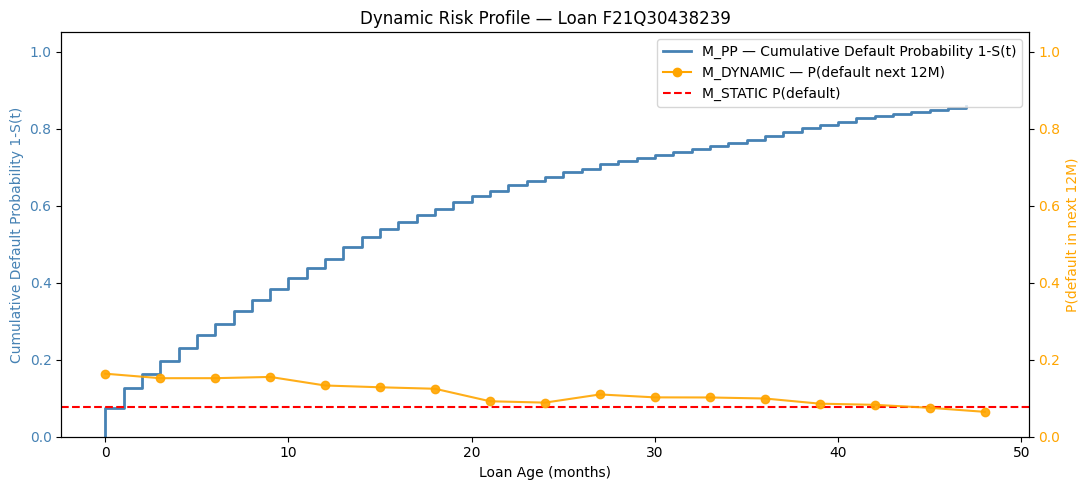

In [86]:
loan_id     = "F21Q30438239"
static_prob = get_static_prob(loan_id, grp_static, static_oof_preds)

plot_loan_dynamic_risk_profile(
    loan_id        = loan_id,
    grp_pp         = grp_pp,
    pp_ages        = pp_ages,
    pp_preds       = pp_oof_preds,
    grp_dyn        = grp_dynamic,
    lmk_vals       = lmk_vals,
    dyn_preds      = dynamic_oof_preds,
    static_survival = static_prob,
)

 La curva ha esattamente la forma che ti aspetteresti da un prestito che effettivamente defaulta intorno al mese 25.

non sta necessariamente a zero a t default, se sta a zero significa che il modello pp è giusto

quindi il problema da gestie è che mpp crolla subito

23:49
Sì, esatto. Il problema centrale è che M_PP assegna hazard altissimi nei primi mesi per la maggior parte dei loan, indipendentemente da quando defaultano realmente.

Cause probabili ancora in piedi
1. Sbilanciamento temporale dei default nel dataset La maggior parte dei default nel dataset Freddie Mac avviene nei primi 12-24 mesi. Il modello impara che loan_age bassa → alto rischio, indipendentemente dalle altre feature.

2. TVC rumorose nei primi mesi current_upb, estimated_ltv, current_interest_rate potrebbero avere valori anomali o mancanti nei primissimi mesi, che il modello interpreta come segnale di stress.

3. age_norm non abbastanza discriminante Il modello non distingue bene tra "loan giovane sano" e "loan giovane a rischio".

In [83]:
truth_df = pd.read_csv(DATA_PATH, usecols=["loan_sequence_number", "current_loan_delinquency_status", "loan_age"])
truth_df["Default"] = is_default_vec(truth_df["current_loan_delinquency_status"])
fd_age = (truth_df[truth_df["Default"] == 1]
          .groupby("loan_sequence_number")["loan_age"].min()
          .rename("FirstDefaultAge"))

# tutti i loan unici, non solo quelli che defaultano
all_loans = truth_df[["loan_sequence_number"]].drop_duplicates()
truth_df  = all_loans.merge(fd_age, on="loan_sequence_number", how="left")

# ora FirstDefaultAge è NaN per i loan sani
non_defaulted_loans = set(truth_df[truth_df["FirstDefaultAge"].isna()]["loan_sequence_number"])
candidates_nd = list(common_loans & non_defaulted_loans)
print(f"Loan non defaultati disponibili: {len(candidates_nd)}")
for loan_id_candidate in candidates_nd[:20]:  # mostra i primi 20
    print(f"  Loan ID: {loan_id_candidate}")

/tmp/ipykernel_12931/2977883970.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  truth_df = pd.read_csv(DATA_PATH, usecols=["loan_sequence_number", "current_loan_delinquency_status", "loan_age"])


Loan non defaultati disponibili: 770
  Loan ID: F24Q20160359
  Loan ID: F21Q12000307
  Loan ID: F21Q40036715
  Loan ID: F20Q41071953
  Loan ID: F20Q30171735
  Loan ID: F24Q40082912
  Loan ID: F20Q20889018
  Loan ID: F24Q10182743
  Loan ID: F21Q30271820
  Loan ID: F20Q20747099
  Loan ID: F19Q20025734
  Loan ID: F24Q20238494
  Loan ID: F24Q10123661
  Loan ID: F24Q30208868
  Loan ID: F20Q31134464
  Loan ID: F20Q20100798
  Loan ID: F20Q31025615
  Loan ID: F21Q30925663
  Loan ID: F21Q30438239
  Loan ID: F22Q10254361


In [84]:
for loan_id_candidate in candidates_nd[:20]:  # mostra i primi 20
    print(f"  Loan ID: {loan_id_candidate}")

  Loan ID: F24Q20160359
  Loan ID: F21Q12000307
  Loan ID: F21Q40036715
  Loan ID: F20Q41071953
  Loan ID: F20Q30171735
  Loan ID: F24Q40082912
  Loan ID: F20Q20889018
  Loan ID: F24Q10182743
  Loan ID: F21Q30271820
  Loan ID: F20Q20747099
  Loan ID: F19Q20025734
  Loan ID: F24Q20238494
  Loan ID: F24Q10123661
  Loan ID: F24Q30208868
  Loan ID: F20Q31134464
  Loan ID: F20Q20100798
  Loan ID: F20Q31025615
  Loan ID: F21Q30925663
  Loan ID: F21Q30438239
  Loan ID: F22Q10254361


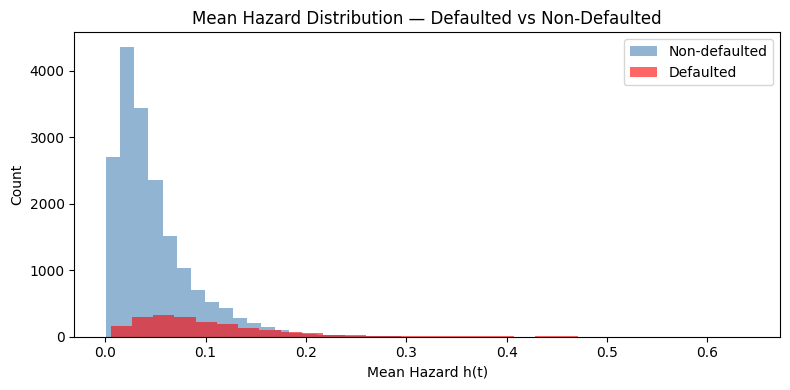

Mean hazard — sani:      0.0478
Mean hazard — defaultati: 0.1057


In [87]:
import matplotlib.pyplot as plt
import numpy as np

# ── loan sani nel test set PP ─────────────────────────────────────────────
pp_test_loans    = grp_pp[pp_test_indices]
pp_test_ages     = pp_ages[pp_test_indices]
pp_test_hazards  = pp_oof_preds[pp_test_indices]

non_defaulted_test = set(grp_pp[pp_test_indices]) & non_defaulted_loans

# hazard medio per ogni loan sano
mean_hazard_healthy = []
mean_hazard_default = []

# loan sani
for loan_id in non_defaulted_test:
    mask = pp_test_loans == loan_id
    hz   = pp_test_hazards[mask]
    mean_hazard_healthy.append(hz.mean())

# loan defaultati
defaulted_test = set(grp_pp[pp_test_indices]) & defaulted_loans
for loan_id in defaulted_test:
    mask = pp_test_loans == loan_id
    hz   = pp_test_hazards[mask]
    mean_hazard_default.append(hz.mean())

mean_hazard_healthy = np.array(mean_hazard_healthy)
mean_hazard_default = np.array(mean_hazard_default)

# ── plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mean_hazard_healthy, bins=30, alpha=0.6, color="steelblue", label="Non-defaulted")
ax.hist(mean_hazard_default, bins=30, alpha=0.6, color="red",       label="Defaulted")
ax.set_xlabel("Mean Hazard h(t)")
ax.set_ylabel("Count")
ax.set_title("Mean Hazard Distribution — Defaulted vs Non-Defaulted")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean hazard — sani:      {mean_hazard_healthy.mean():.4f}")
print(f"Mean hazard — defaultati: {mean_hazard_default.mean():.4f}")

In [88]:
print(f"Mean hazard — sani:       {mean_hazard_healthy.mean():.4f}")
print(f"Mean hazard — defaultati: {mean_hazard_default.mean():.4f}")
print(f"% defaultati con hazard > 0.05: {(mean_hazard_default > 0.05).mean()*100:.1f}%")
print(f"% sani con hazard > 0.05:       {(mean_hazard_healthy > 0.05).mean()*100:.1f}%")

Mean hazard — sani:       0.0478
Mean hazard — defaultati: 0.1057
% defaultati con hazard > 0.05: 74.9%
% sani con hazard > 0.05:       34.5%
